In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/train.csv.zip
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/sampleSubmission.csv.zip
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/stores.csv
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/features.csv.zip
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/test.csv.zip


In [8]:
from pathlib import Path

import pandas as pd

DATA_DIR = Path("/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/")


def find_dataset_file(name: str) -> Path:
    possible_paths = [
        DATA_DIR / f"{name}.csv",
        DATA_DIR / f"{name}.csv.zip",
        DATA_DIR / f"{name}.zip",
    ]

    for path in possible_paths:
        if path.exists():
            return path

    raise FileNotFoundError(
        f"Could not find {name}.csv or a zipped version in "
        f"{DATA_DIR.resolve()}"
    )


train = pd.read_csv(
    find_dataset_file("train"),
    parse_dates=["Date"],
)

test = pd.read_csv(
    find_dataset_file("test"),
    parse_dates=["Date"],
)

features = pd.read_csv(
    find_dataset_file("features"),
    parse_dates=["Date"],
)

stores = pd.read_csv(
    find_dataset_file("stores"),
)

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [9]:
datasets = {
    "train": train,
    "test": test,
    "features": features,
    "stores": stores,
}

for name, df in datasets.items():
    print("=" * 80)
    print(name.upper())
    print("=" * 80)

    print(f"Rows: {len(df):,}")
    print(f"Columns: {df.shape[1]}")
    print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nData types:")
    print(df.dtypes)

    print("\nFirst five rows:")
    display(df.head())

TRAIN
Rows: 421,570
Columns: 5
Memory usage: 13.27 MB

Columns:
['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']

Data types:
Store                    int64
Dept                     int64
Date            datetime64[ns]
Weekly_Sales           float64
IsHoliday                 bool
dtype: object

First five rows:


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,"24,924.50",False
1,1,1,2010-02-12,"46,039.49",True
2,1,1,2010-02-19,"41,595.55",False
3,1,1,2010-02-26,"19,403.54",False
4,1,1,2010-03-05,"21,827.90",False


TEST
Rows: 115,064
Columns: 4
Memory usage: 2.74 MB

Columns:
['Store', 'Dept', 'Date', 'IsHoliday']

Data types:
Store                 int64
Dept                  int64
Date         datetime64[ns]
IsHoliday              bool
dtype: object

First five rows:


,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False


FEATURES
Rows: 8,190
Columns: 12
Memory usage: 0.70 MB

Columns:
['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday']

Data types:
Store                    int64
Date            datetime64[ns]
Temperature            float64
Fuel_Price             float64
MarkDown1              float64
MarkDown2              float64
MarkDown3              float64
MarkDown4              float64
MarkDown5              float64
CPI                    float64
Unemployment           float64
IsHoliday                 bool
dtype: object

First five rows:


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.57,NaN,NaN,NaN,NaN,NaN,211.10,8.11,False
1,1,2010-02-12,38.51,2.55,NaN,NaN,NaN,NaN,NaN,211.24,8.11,True
2,1,2010-02-19,39.93,2.51,NaN,NaN,NaN,NaN,NaN,211.29,8.11,False
3,1,2010-02-26,46.63,2.56,NaN,NaN,NaN,NaN,NaN,211.32,8.11,False
4,1,2010-03-05,46.50,2.62,NaN,NaN,NaN,NaN,NaN,211.35,8.11,False


STORES
Rows: 45
Columns: 3
Memory usage: 0.00 MB

Columns:
['Store', 'Type', 'Size']

Data types:
Store     int64
Type     object
Size      int64
dtype: object

First five rows:


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [10]:
for df in [train, test, features]:
    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print(train.dtypes)

Store                    int64
Dept                     int64
Date            datetime64[ns]
Weekly_Sales           float64
IsHoliday                 bool
dtype: object


In [11]:
for name, df in datasets.items():
    if "Date" in df.columns:
        invalid_dates = df["Date"].isna().sum()
        print(f"{name}: {invalid_dates:,} invalid dates")

train: 0 invalid dates
test: 0 invalid dates
features: 0 invalid dates


In [12]:
def dataset_summary(df: pd.DataFrame, name: str) -> pd.DataFrame:
    summary = pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "non_null": df.notna().sum().values,
        "missing": df.isna().sum().values,
        "missing_pct": (df.isna().mean() * 100).values,
        "unique_values": df.nunique(dropna=False).values,
    })

    summary["dataset"] = name

    return summary[
        [
            "dataset",
            "column",
            "dtype",
            "non_null",
            "missing",
            "missing_pct",
            "unique_values",
        ]
    ]


all_summaries = pd.concat(
    [
        dataset_summary(train, "train"),
        dataset_summary(test, "test"),
        dataset_summary(features, "features"),
        dataset_summary(stores, "stores"),
    ],
    ignore_index=True,
)

display(all_summaries)

,dataset,column,dtype,non_null,missing,missing_pct,unique_values
0,train,Store,int64,421570,0,0.00,45
1,train,Dept,int64,421570,0,0.00,81
2,train,Date,datetime64[ns],421570,0,0.00,143
3,train,Weekly_Sales,float64,421570,0,0.00,359464
4,train,IsHoliday,bool,421570,0,0.00,2
5,test,Store,int64,115064,0,0.00,45
6,test,Dept,int64,115064,0,0.00,81
7,test,Date,datetime64[ns],115064,0,0.00,39
8,test,IsHoliday,bool,115064,0,0.00,2
9,features,Store,int64,8190,0,0.00,45


In [13]:
def missing_value_report(df: pd.DataFrame) -> pd.DataFrame:
    report = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_percentage": df.isna().mean() * 100,
    })

    report = report[report["missing_count"] > 0]
    return report.sort_values("missing_percentage", ascending=False)


for name, df in datasets.items():
    print(f"\nMissing values in {name}:")
    display(missing_value_report(df))


Missing values in train:


,missing_count,missing_percentage



Missing values in test:


,missing_count,missing_percentage



Missing values in features:


,missing_count,missing_percentage
MarkDown2,5269,64.33
MarkDown4,4726,57.70
MarkDown3,4577,55.89
MarkDown1,4158,50.77
MarkDown5,4140,50.55
CPI,585,7.14
Unemployment,585,7.14



Missing values in stores:


,missing_count,missing_percentage


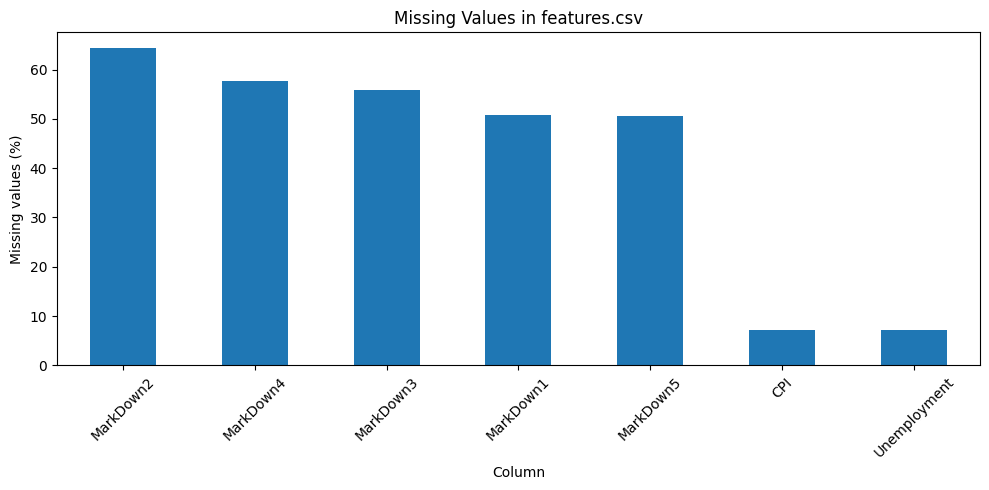

In [14]:
missing = features.isna().mean().mul(100).sort_values(ascending=False)
missing = missing[missing > 0]

plt.figure(figsize=(10, 5))
missing.plot(kind="bar")
plt.title("Missing Values in features.csv")
plt.ylabel("Missing values (%)")
plt.xlabel("Column")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
features_filled = features.copy()

markdown_columns = [
    column for column in features_filled.columns
    if column.startswith("MarkDown")
]

features_filled[markdown_columns] = (
    features_filled[markdown_columns].fillna(0)
)

In [16]:
key_columns = {
    "train": ["Store", "Dept", "Date"],
    "test": ["Store", "Dept", "Date"],
    "features": ["Store", "Date"],
    "stores": ["Store"],
}

for name, df in datasets.items():
    keys = key_columns[name]

    duplicate_count = df.duplicated(subset=keys).sum()

    print(
        f"{name}: {duplicate_count:,} duplicate rows "
        f"based on {keys}"
    )

train: 0 duplicate rows based on ['Store', 'Dept', 'Date']
test: 0 duplicate rows based on ['Store', 'Dept', 'Date']
features: 0 duplicate rows based on ['Store', 'Date']
stores: 0 duplicate rows based on ['Store']


In [17]:
for name, df in {
    "train": train,
    "test": test,
    "features": features,
}.items():
    print(f"\n{name.upper()}")
    print("Minimum date:", df["Date"].min())
    print("Maximum date:", df["Date"].max())
    print("Number of unique dates:", df["Date"].nunique())


TRAIN
Minimum date: 2010-02-05 00:00:00
Maximum date: 2012-10-26 00:00:00
Number of unique dates: 143

TEST
Minimum date: 2012-11-02 00:00:00
Maximum date: 2013-07-26 00:00:00
Number of unique dates: 39

FEATURES
Minimum date: 2010-02-05 00:00:00
Maximum date: 2013-07-26 00:00:00
Number of unique dates: 182


In [18]:
print("Number of stores:", train["Store"].nunique())
print("Number of departments:", train["Dept"].nunique())
print(
    "Number of store-department combinations:",
    train[["Store", "Dept"]].drop_duplicates().shape[0],
)
print("Number of training weeks:", train["Date"].nunique())

Number of stores: 45
Number of departments: 81
Number of store-department combinations: 3331
Number of training weeks: 143


,Store,Dept,number_of_weeks
count,"3,331.00","3,331.00","3,331.00"
mean,22.50,45.72,126.56
std,12.83,30.15,40.21
min,1.00,1.00,1.00
25%,11.00,20.00,143.00
50%,22.00,41.00,143.00
75%,33.00,74.00,143.00
max,45.00,99.00,143.00


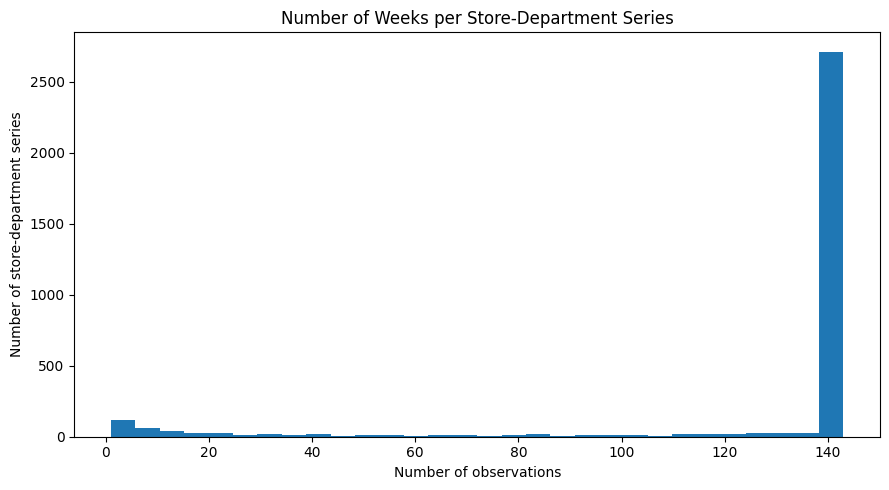

In [20]:
series_lengths = (
    train.groupby(["Store", "Dept"])
    .size()
    .rename("number_of_weeks")
    .reset_index()
)

display(series_lengths.describe())

plt.figure(figsize=(9, 5))
plt.hist(series_lengths["number_of_weeks"], bins=30)
plt.title("Number of Weeks per Store-Department Series")
plt.xlabel("Number of observations")
plt.ylabel("Number of store-department series")
plt.tight_layout()
plt.show()

In [21]:
train_pairs = set(
    map(
        tuple,
        train[["Store", "Dept"]]
        .drop_duplicates()
        .to_numpy(),
    )
)

test_pairs = set(
    map(
        tuple,
        test[["Store", "Dept"]]
        .drop_duplicates()
        .to_numpy(),
    )
)

print("Pairs in train:", len(train_pairs))
print("Pairs in test:", len(test_pairs))
print("Pairs in both:", len(train_pairs & test_pairs))
print("Pairs only in train:", len(train_pairs - test_pairs))
print("Pairs only in test:", len(test_pairs - train_pairs))

Pairs in train: 3331
Pairs in test: 3169
Pairs in both: 3158
Pairs only in train: 173
Pairs only in test: 11


In [22]:
sales_summary = train["Weekly_Sales"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

display(sales_summary)

count   421,570.00
mean     15,981.26
std      22,711.18
min      -4,988.94
1%            5.00
5%           59.97
25%       2,079.65
50%       7,612.03
75%      20,205.85
95%      61,201.95
99%     106,479.59
max     693,099.36
Name: Weekly_Sales, dtype: float64

In [23]:
print(
    "Negative sales:",
    (train["Weekly_Sales"] < 0).sum(),
)

print(
    "Zero sales:",
    (train["Weekly_Sales"] == 0).sum(),
)

print(
    "Positive sales:",
    (train["Weekly_Sales"] > 0).sum(),
)

Negative sales: 1285
Zero sales: 73
Positive sales: 420212


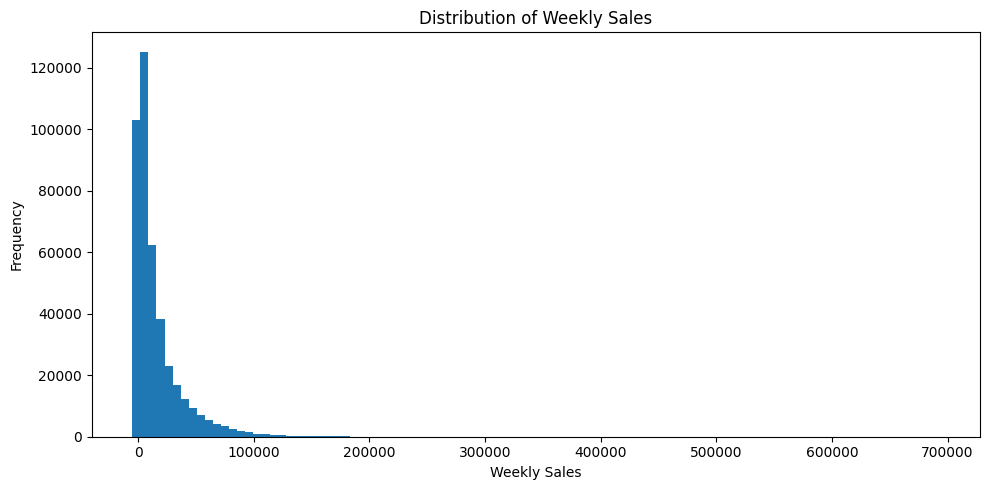

In [24]:
plt.figure(figsize=(10, 5))
plt.hist(train["Weekly_Sales"], bins=100)
plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

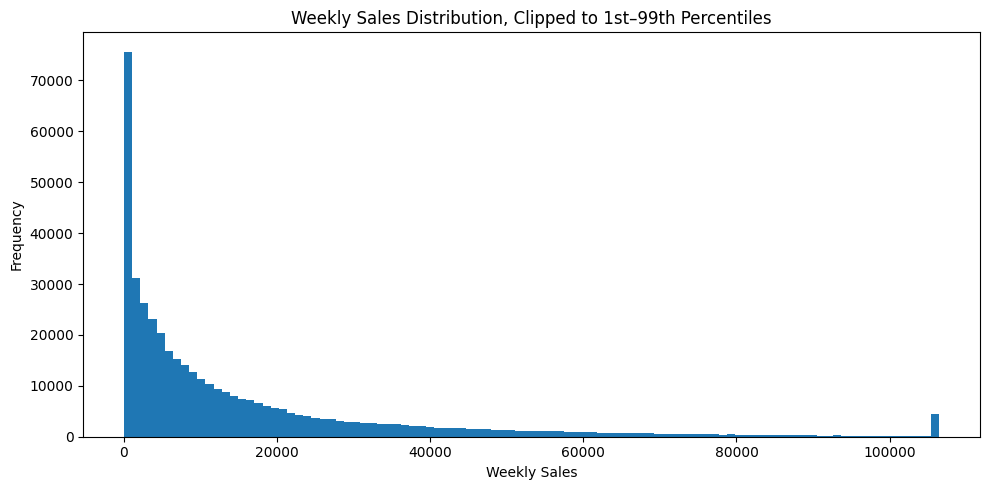

In [25]:
lower_limit = train["Weekly_Sales"].quantile(0.01)
upper_limit = train["Weekly_Sales"].quantile(0.99)

clipped_sales = train["Weekly_Sales"].clip(
    lower=lower_limit,
    upper=upper_limit,
)

plt.figure(figsize=(10, 5))
plt.hist(clipped_sales, bins=100)
plt.title("Weekly Sales Distribution, Clipped to 1st–99th Percentiles")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

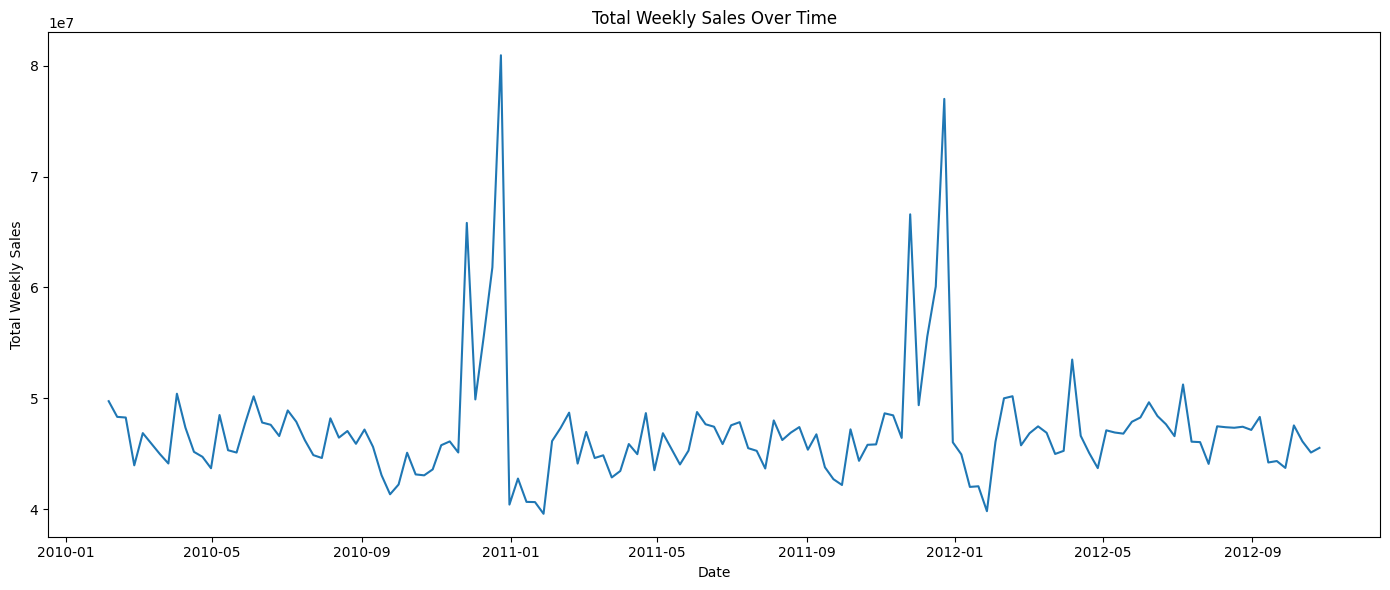

In [26]:
weekly_total_sales = (
    train.groupby("Date", as_index=False)["Weekly_Sales"]
    .sum()
    .sort_values("Date")
)

plt.figure(figsize=(14, 6))
plt.plot(
    weekly_total_sales["Date"],
    weekly_total_sales["Weekly_Sales"],
)
plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales")
plt.tight_layout()
plt.show()

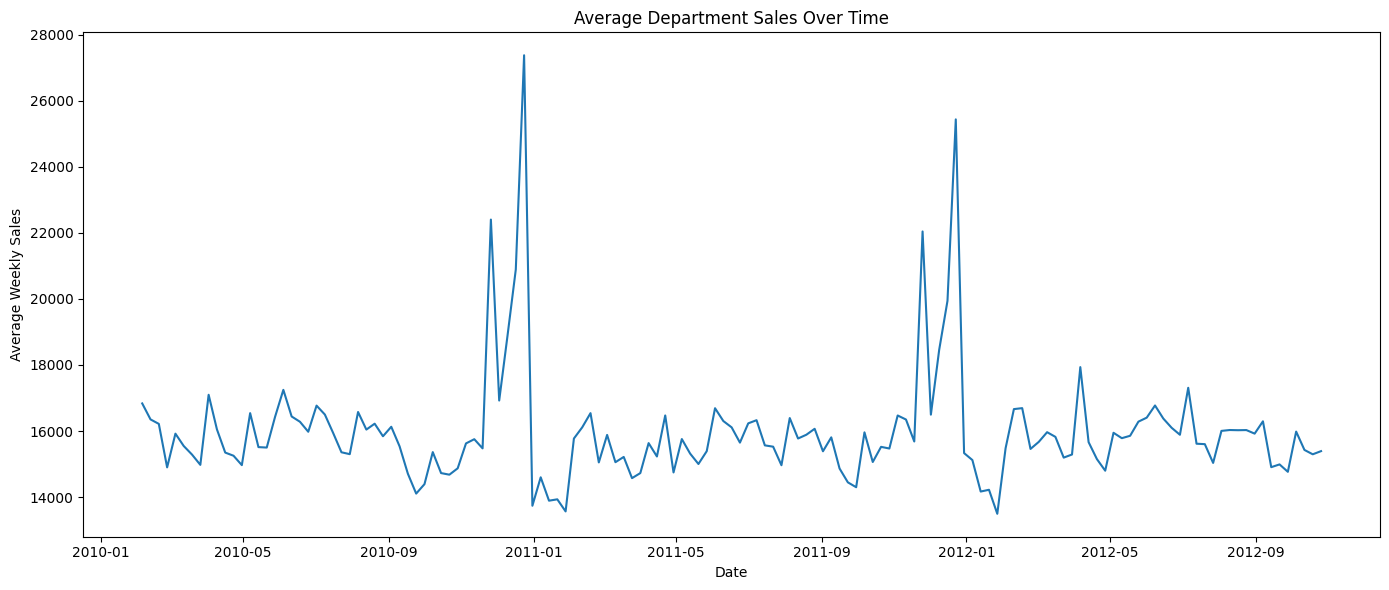

In [27]:
weekly_average_sales = (
    train.groupby("Date", as_index=False)["Weekly_Sales"]
    .mean()
    .sort_values("Date")
)

plt.figure(figsize=(14, 6))
plt.plot(
    weekly_average_sales["Date"],
    weekly_average_sales["Weekly_Sales"],
)
plt.title("Average Department Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Average Weekly Sales")
plt.tight_layout()
plt.show()

In [28]:
holiday_summary = (
    train.groupby("IsHoliday")["Weekly_Sales"]
    .agg(
        rows="size",
        mean="mean",
        median="median",
        total="sum",
        standard_deviation="std",
    )
)

display(holiday_summary)

,rows,mean,median,total,standard_deviation
IsHoliday,,,,,
False,391909,"15,901.45","7,589.95","6,231,919,435.55","22,330.75"
True,29661,"17,035.82","7,947.74","505,299,551.56","27,222.00"


In [29]:
holiday_counts = train["IsHoliday"].value_counts(dropna=False)
holiday_percentages = train["IsHoliday"].value_counts(
    normalize=True,
    dropna=False,
).mul(100)

holiday_report = pd.DataFrame({
    "count": holiday_counts,
    "percentage": holiday_percentages,
})

display(holiday_report)

,count,percentage
IsHoliday,,
False,391909,92.96
True,29661,7.04


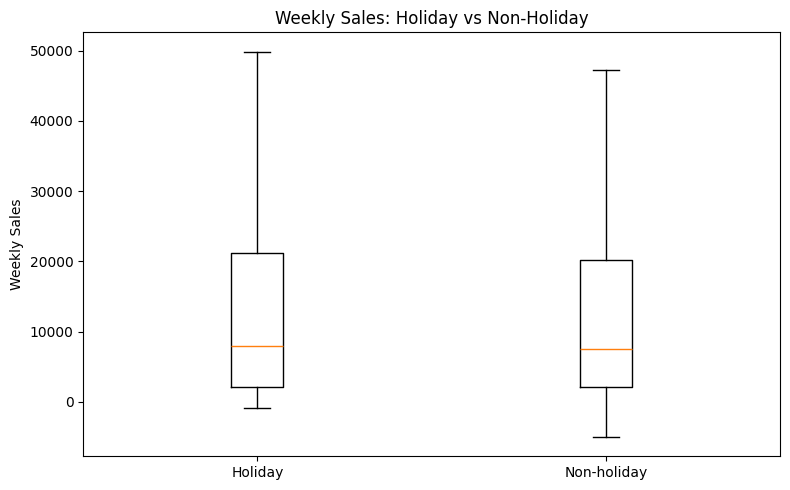

In [30]:
holiday_sales = train.loc[
    train["IsHoliday"],
    "Weekly_Sales",
]

non_holiday_sales = train.loc[
    ~train["IsHoliday"],
    "Weekly_Sales",
]

plot_data = [
    holiday_sales.clip(
        upper=holiday_sales.quantile(0.99)
    ),
    non_holiday_sales.clip(
        upper=non_holiday_sales.quantile(0.99)
    ),
]

plt.figure(figsize=(8, 5))
plt.boxplot(
    plot_data,
    tick_labels=["Holiday", "Non-holiday"],
    showfliers=False,
)
plt.title("Weekly Sales: Holiday vs Non-Holiday")
plt.ylabel("Weekly Sales")
plt.tight_layout()
plt.show()

In [31]:
holiday_dates = (
    train.loc[train["IsHoliday"], ["Date"]]
    .drop_duplicates()
    .sort_values("Date")
    .reset_index(drop=True)
)

display(holiday_dates)

,Date
0,2010-02-12
1,2010-09-10
2,2010-11-26
3,2010-12-31
4,2011-02-11
5,2011-09-09
6,2011-11-25
7,2011-12-30
8,2012-02-10
9,2012-09-07


In [32]:
holiday_week_sales = (
    train.loc[train["IsHoliday"]]
    .groupby("Date", as_index=False)["Weekly_Sales"]
    .sum()
    .sort_values("Date")
)

display(holiday_week_sales)

,Date,Weekly_Sales
0,2010-02-12,"48,336,677.63"
1,2010-09-10,"45,634,397.84"
2,2010-11-26,"65,821,003.24"
3,2010-12-31,"40,432,519.00"
4,2011-02-11,"47,336,192.79"
5,2011-09-09,"46,763,227.53"
6,2011-11-25,"66,593,605.26"
7,2011-12-30,"46,042,461.04"
8,2012-02-10,"50,009,407.92"
9,2012-09-07,"48,330,059.31"


In [33]:
store_sales = (
    train.groupby("Store")["Weekly_Sales"]
    .agg(
        total_sales="sum",
        average_sales="mean",
        median_sales="median",
        observations="size",
    )
    .sort_values("total_sales", ascending=False)
)

display(store_sales.head(15))

,total_sales,average_sales,median_sales,observations
Store,,,,
20,"301,397,792.46","29,508.30","16,249.78",10214
4,"299,543,953.38","29,161.21","15,116.81",10272
14,"288,999,911.34","28,784.85","15,208.81",10040
13,"286,517,703.80","27,355.14","14,018.45",10474
2,"275,382,440.98","26,898.07","14,333.53",10238
10,"271,617,713.89","26,332.30","13,941.43",10315
27,"253,855,916.88","24,826.98","13,625.95",10225
6,"223,756,130.64","21,913.24","13,637.84",10211
1,"222,402,808.85","21,710.54","10,289.38",10244


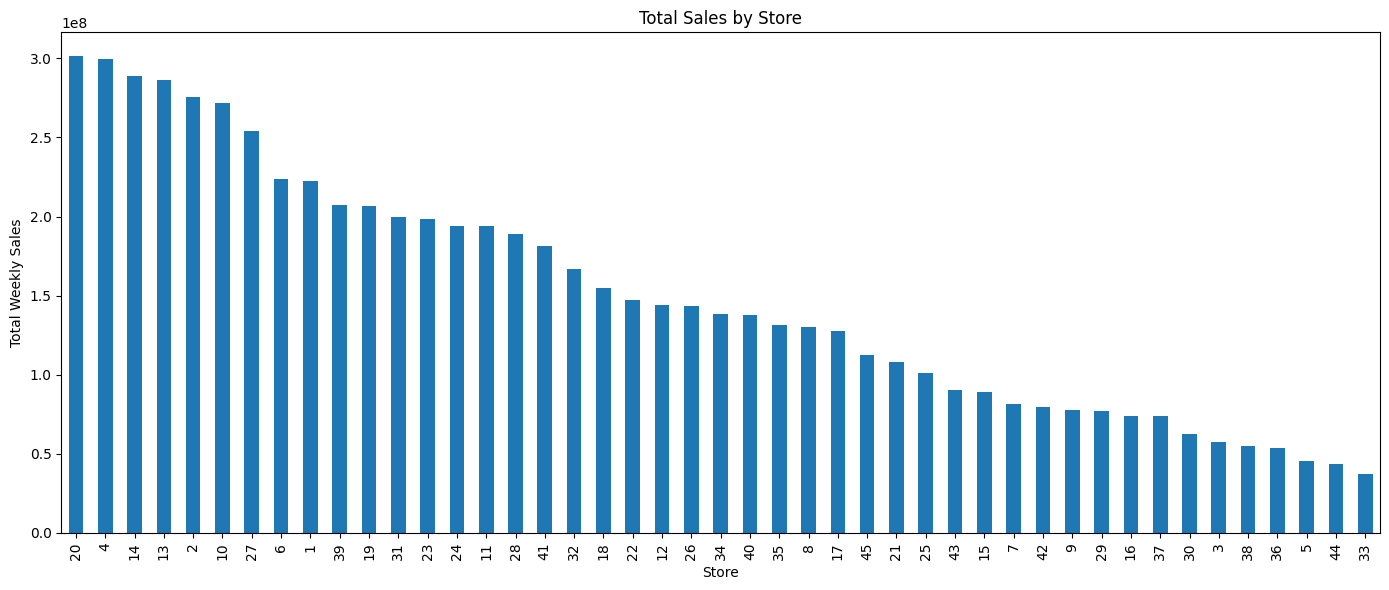

In [34]:
plt.figure(figsize=(14, 6))
store_sales["total_sales"].plot(kind="bar")
plt.title("Total Sales by Store")
plt.xlabel("Store")
plt.ylabel("Total Weekly Sales")
plt.tight_layout()
plt.show()

In [35]:
department_sales = (
    train.groupby("Dept")["Weekly_Sales"]
    .agg(
        total_sales="sum",
        average_sales="mean",
        median_sales="median",
        observations="size",
    )
    .sort_values("total_sales", ascending=False)
)

display(department_sales.head(20))

,total_sales,average_sales,median_sales,observations
Dept,,,,
92,"483,943,341.87","75,204.87","61,816.77",6435
95,"449,320,162.52","69,824.42","60,774.39",6435
38,"393,118,136.92","61,090.62","57,336.65",6435
72,"305,725,152.21","50,566.52","44,312.36",6046
90,"291,068,463.68","45,232.08","40,535.79",6435
40,"288,936,022.05","44,900.70","42,717.87",6435
2,"280,611,174.43","43,607.02","41,412.61",6435
91,"216,781,705.73","33,687.91","31,033.63",6435
13,"197,321,569.95","30,663.80","27,970.82",6435


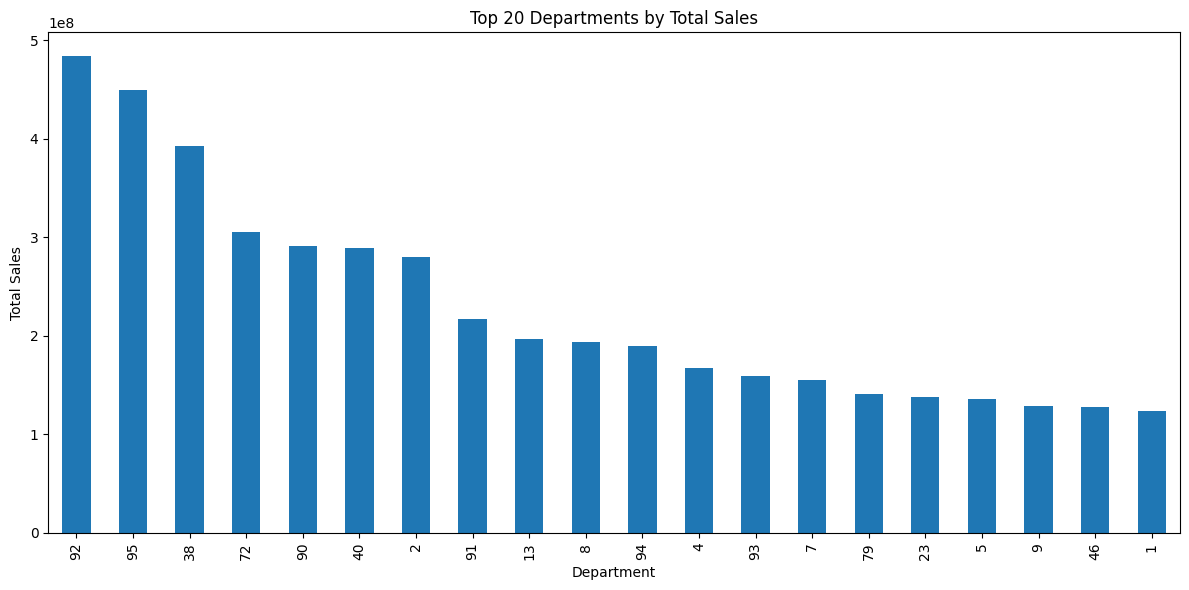

In [36]:
top_departments = department_sales.head(20)

plt.figure(figsize=(12, 6))
top_departments["total_sales"].plot(kind="bar")
plt.title("Top 20 Departments by Total Sales")
plt.xlabel("Department")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

In [37]:
train_merged = (
    train
    .merge(
        features,
        on=["Store", "Date", "IsHoliday"],
        how="left",
        validate="many_to_one",
    )
    .merge(
        stores,
        on="Store",
        how="left",
        validate="many_to_one",
    )
)

test_merged = (
    test
    .merge(
        features,
        on=["Store", "Date", "IsHoliday"],
        how="left",
        validate="many_to_one",
    )
    .merge(
        stores,
        on="Store",
        how="left",
        validate="many_to_one",
    )
)

print("Merged train shape:", train_merged.shape)
print("Merged test shape:", test_merged.shape)

display(train_merged.head())

Merged train shape: (421570, 16)
Merged test shape: (115064, 15)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,"24,924.50",False,42.31,2.57,NaN,NaN,NaN,NaN,NaN,211.10,8.11,A,151315
1,1,1,2010-02-12,"46,039.49",True,38.51,2.55,NaN,NaN,NaN,NaN,NaN,211.24,8.11,A,151315
2,1,1,2010-02-19,"41,595.55",False,39.93,2.51,NaN,NaN,NaN,NaN,NaN,211.29,8.11,A,151315
3,1,1,2010-02-26,"19,403.54",False,46.63,2.56,NaN,NaN,NaN,NaN,NaN,211.32,8.11,A,151315
4,1,1,2010-03-05,"21,827.90",False,46.50,2.62,NaN,NaN,NaN,NaN,NaN,211.35,8.11,A,151315


In [38]:
print("Train rows before merge:", len(train))
print("Train rows after merge:", len(train_merged))

print("\nMissing merged store types:")
print(train_merged["Type"].isna().sum())

print("\nMissing merged store sizes:")
print(train_merged["Size"].isna().sum())

Train rows before merge: 421570
Train rows after merge: 421570

Missing merged store types:
0

Missing merged store sizes:
0


In [39]:
store_type_summary = (
    train_merged.groupby("Type")["Weekly_Sales"]
    .agg(
        stores=lambda x: train_merged.loc[x.index, "Store"].nunique(),
        observations="size",
        total_sales="sum",
        average_sales="mean",
        median_sales="median",
    )
)

display(store_type_summary)

,stores,observations,total_sales,average_sales,median_sales
Type,,,,,
A,22,215478,"4,331,014,722.75","20,099.57","10,105.17"
B,17,163495,"2,000,700,736.82","12,237.08","6,187.87"
C,6,42597,"405,503,527.54","9,519.53","1,149.67"


In [40]:
display(stores["Size"].describe())

count        45.00
mean    130,287.60
std      63,825.27
min      34,875.00
25%      70,713.00
50%     126,512.00
75%     202,307.00
max     219,622.00
Name: Size, dtype: float64

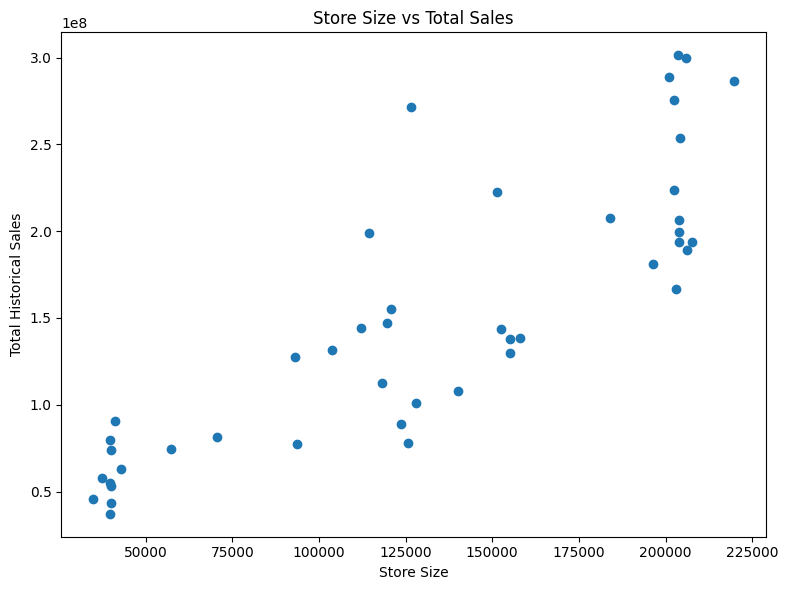

Correlation: 0.8461612451718923


In [41]:
sales_by_store = (
    train.groupby("Store", as_index=False)["Weekly_Sales"]
    .sum()
    .rename(columns={"Weekly_Sales": "Total_Sales"})
)

store_size_sales = stores.merge(
    sales_by_store,
    on="Store",
    how="left",
)

plt.figure(figsize=(8, 6))
plt.scatter(
    store_size_sales["Size"],
    store_size_sales["Total_Sales"],
)
plt.title("Store Size vs Total Sales")
plt.xlabel("Store Size")
plt.ylabel("Total Historical Sales")
plt.tight_layout()
plt.show()

correlation = store_size_sales[
    ["Size", "Total_Sales"]
].corr().iloc[0, 1]

print("Correlation:", correlation)

In [42]:
numeric_columns = [
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5",
    "Size",
    "Weekly_Sales",
]

available_numeric_columns = [
    column
    for column in numeric_columns
    if column in train_merged.columns
]

display(
    train_merged[available_numeric_columns].describe().T
)

,count,mean,std,min,25%,50%,75%,max
Temperature,"421,570.00",60.09,18.45,-2.06,46.68,62.09,74.28,100.14
Fuel_Price,"421,570.00",3.36,0.46,2.47,2.93,3.45,3.74,4.47
CPI,"421,570.00",171.20,39.16,126.06,132.02,182.32,212.42,227.23
Unemployment,"421,570.00",7.96,1.86,3.88,6.89,7.87,8.57,14.31
MarkDown1,"150,681.00","7,246.42","8,291.22",0.27,"2,240.27","5,347.45","9,210.90","88,646.76"
MarkDown2,"111,248.00","3,334.63","9,475.36",-265.76,41.60,192.00,"1,926.94","104,519.54"
MarkDown3,"137,091.00","1,439.42","9,623.08",-29.10,5.08,24.60,103.99,"141,630.61"
MarkDown4,"134,967.00","3,383.17","6,292.38",0.22,504.22,"1,481.31","3,595.04","67,474.85"
MarkDown5,"151,432.00","4,628.98","5,962.89",135.16,"1,878.44","3,359.45","5,563.80","108,519.28"
Size,"421,570.00","136,727.92","60,980.58","34,875.00","93,638.00","140,167.00","202,505.00","219,622.00"


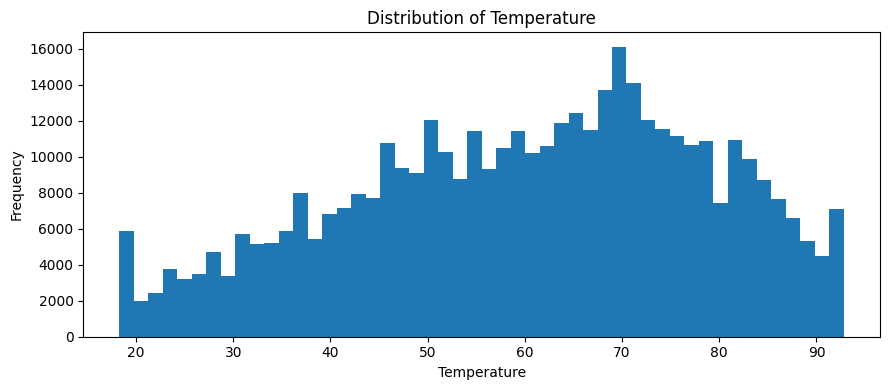

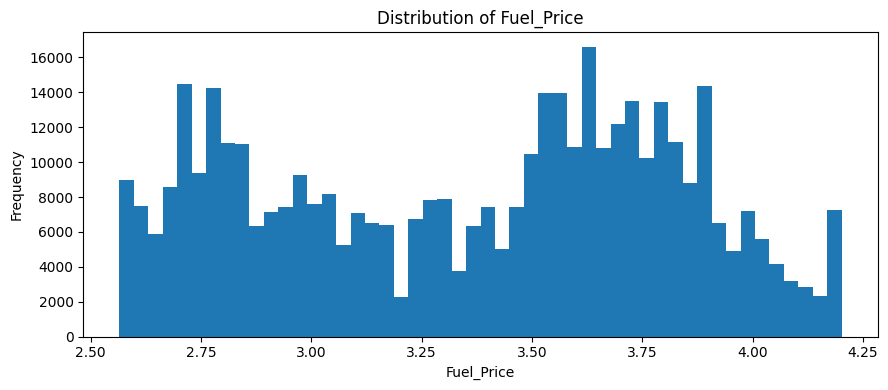

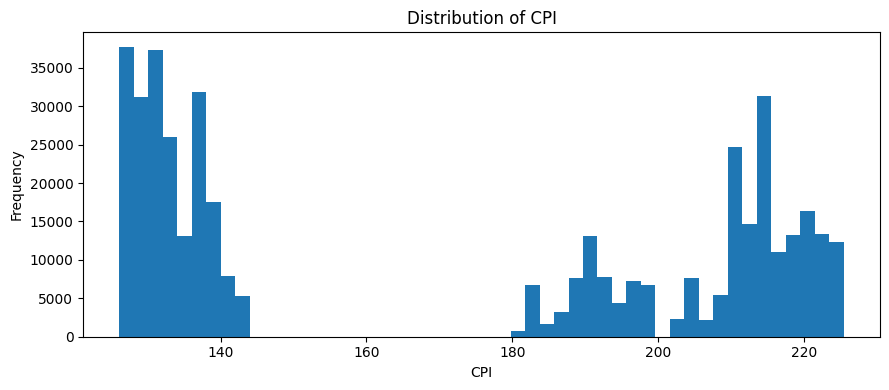

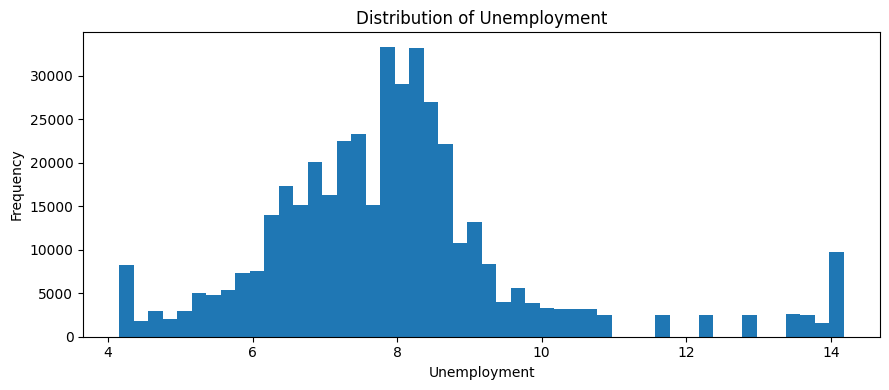

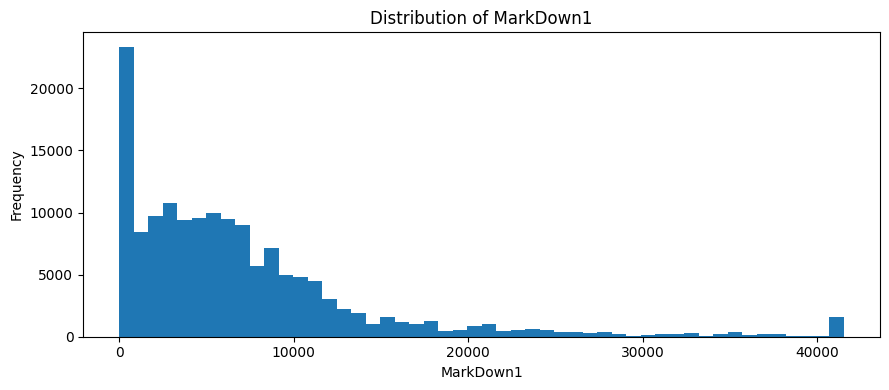

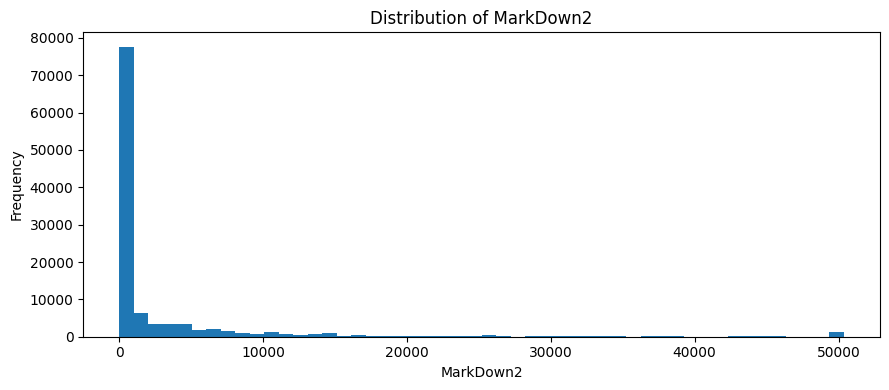

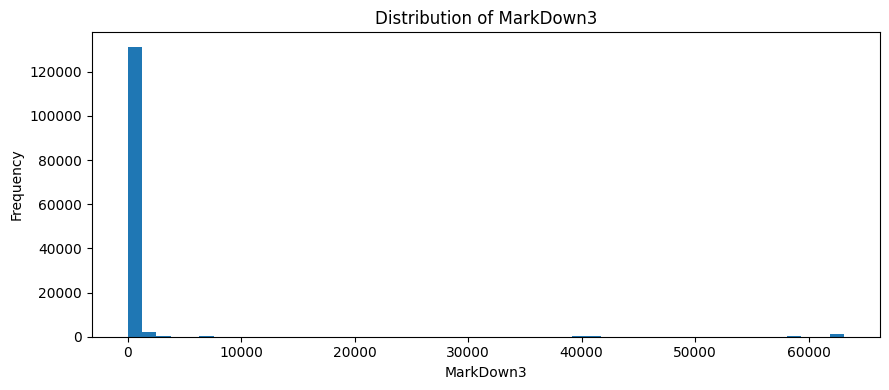

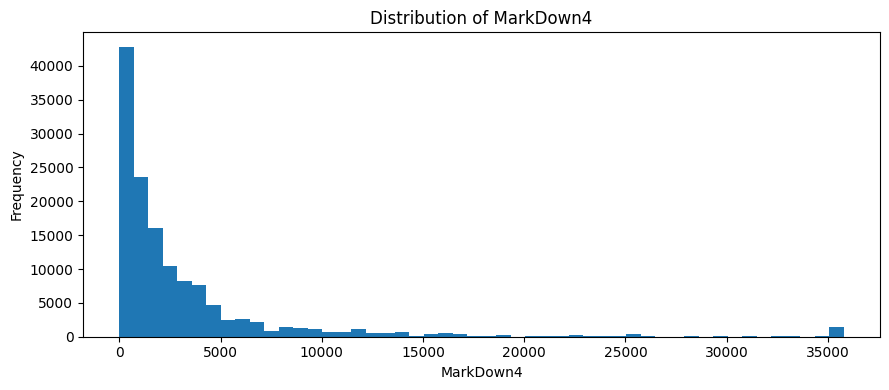

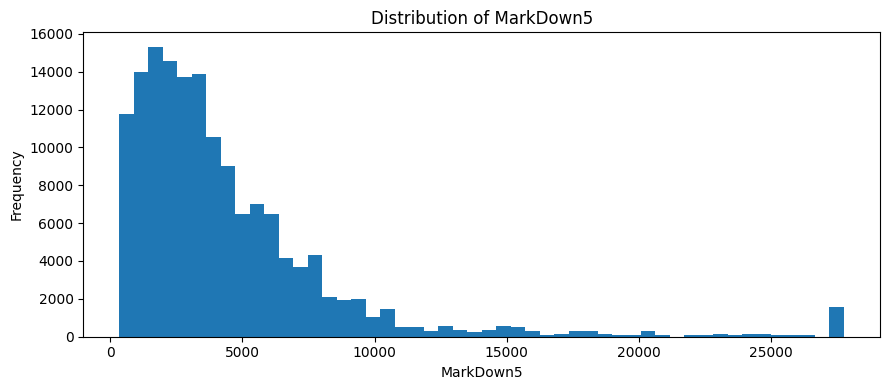

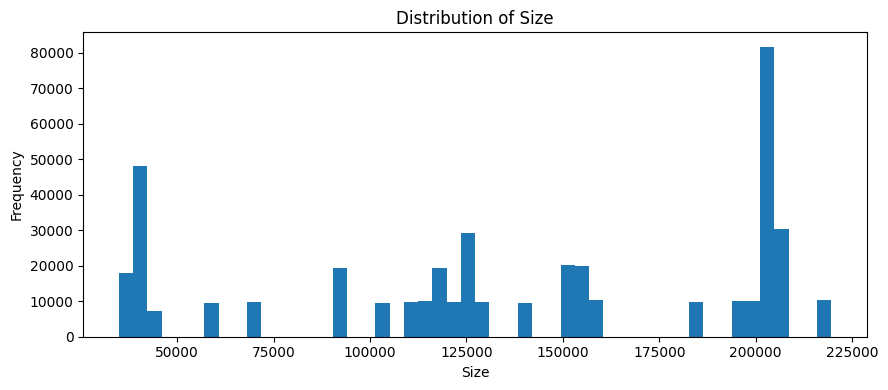

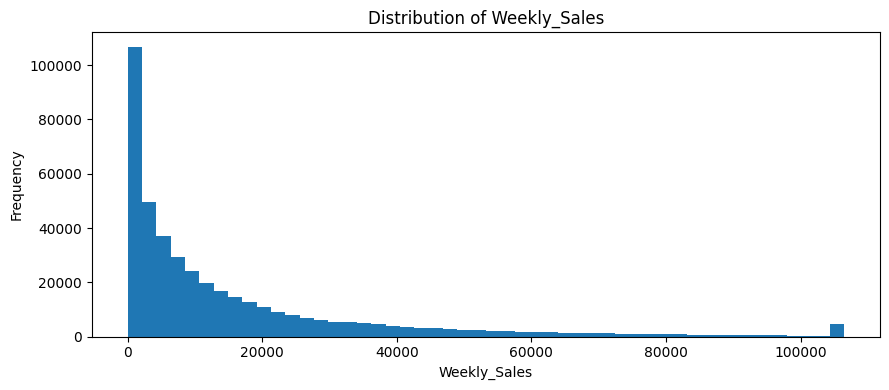

In [43]:
for column in available_numeric_columns:
    values = train_merged[column].dropna()

    if values.empty:
        continue

    lower = values.quantile(0.01)
    upper = values.quantile(0.99)
    values_for_plot = values.clip(lower, upper)

    plt.figure(figsize=(9, 4))
    plt.hist(values_for_plot, bins=50)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

In [44]:
correlation_columns = [
    "Weekly_Sales",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5",
    "Size",
]

correlation_columns = [
    column
    for column in correlation_columns
    if column in train_merged.columns
]

correlation_matrix = (
    train_merged[correlation_columns]
    .corr(method="spearman")
)

display(correlation_matrix.round(3))

,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,Size
Weekly_Sales,1.00,-0.02,0.00,-0.02,-0.02,0.19,0.03,0.14,0.11,0.21,0.29
Temperature,-0.02,1.00,0.13,0.17,0.03,0.00,-0.46,-0.26,0.14,-0.07,-0.04
Fuel_Price,0.00,0.13,1.00,-0.04,-0.06,0.16,-0.15,-0.22,0.07,-0.09,0.00
CPI,-0.02,0.17,-0.04,1.00,-0.38,-0.02,-0.10,-0.11,-0.06,0.02,-0.01
Unemployment,-0.02,0.03,-0.06,-0.38,1.00,0.06,0.06,0.04,0.04,-0.02,-0.07
MarkDown1,0.19,0.00,0.16,-0.02,0.06,1.00,0.21,0.15,0.76,0.51,0.50
MarkDown2,0.03,-0.46,-0.15,-0.10,0.06,0.21,1.00,0.07,0.12,0.15,0.15
MarkDown3,0.14,-0.26,-0.22,-0.11,0.04,0.15,0.07,1.00,0.00,0.24,0.30
MarkDown4,0.11,0.14,0.07,-0.06,0.04,0.76,0.12,0.00,1.00,0.38,0.29
MarkDown5,0.21,-0.07,-0.09,0.02,-0.02,0.51,0.15,0.24,0.38,1.00,0.58


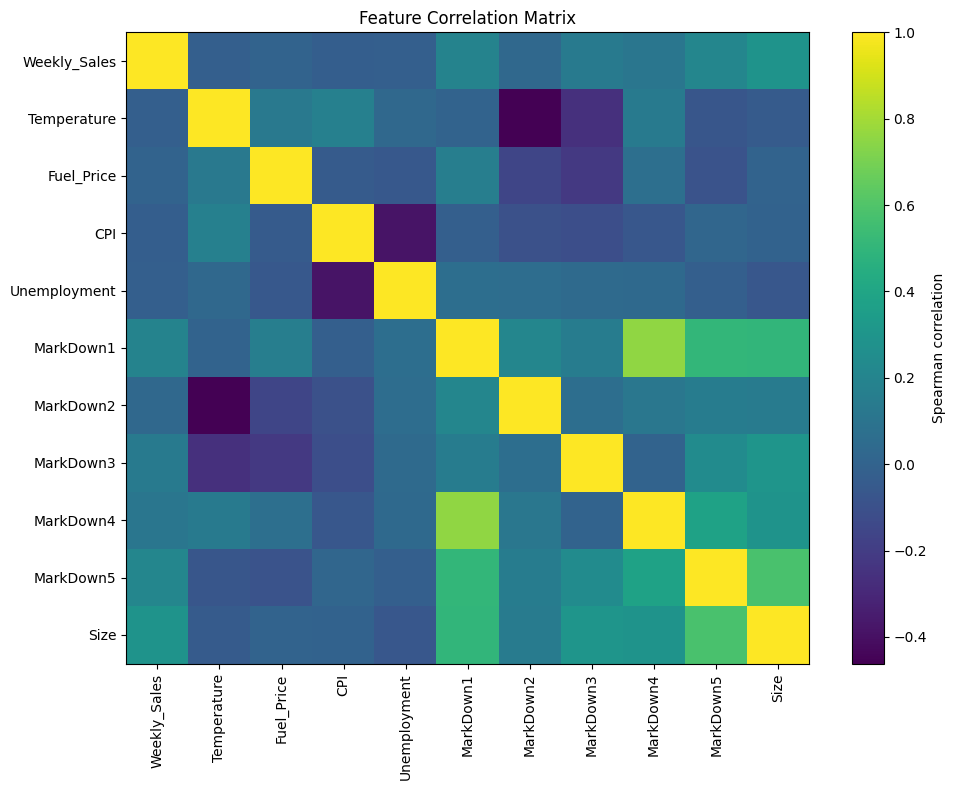

In [45]:
plt.figure(figsize=(10, 8))
plt.imshow(
    correlation_matrix,
    aspect="auto",
)
plt.colorbar(label="Spearman correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90,
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index,
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [46]:
markdown_columns = [
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5",
]

markdown_availability = pd.DataFrame({
    "non_missing": train_merged[markdown_columns].notna().sum(),
    "missing": train_merged[markdown_columns].isna().sum(),
    "available_pct": (
        train_merged[markdown_columns].notna().mean() * 100
    ),
})

display(markdown_availability)

,non_missing,missing,available_pct
MarkDown1,150681,270889,35.74
MarkDown2,111248,310322,26.39
MarkDown3,137091,284479,32.52
MarkDown4,134967,286603,32.02
MarkDown5,151432,270138,35.92


In [47]:
markdown_effects = []

for column in markdown_columns:
    present = train_merged[column].notna() & (
        train_merged[column] != 0
    )

    markdown_effects.append({
        "markdown": column,
        "rows_with_markdown": int(present.sum()),
        "mean_sales_with_markdown": (
            train_merged.loc[present, "Weekly_Sales"].mean()
        ),
        "mean_sales_without_markdown": (
            train_merged.loc[~present, "Weekly_Sales"].mean()
        ),
        "median_sales_with_markdown": (
            train_merged.loc[present, "Weekly_Sales"].median()
        ),
        "median_sales_without_markdown": (
            train_merged.loc[~present, "Weekly_Sales"].median()
        ),
    })

markdown_effect_report = pd.DataFrame(markdown_effects)

display(markdown_effect_report)

,markdown,rows_with_markdown,mean_sales_with_markdown,mean_sales_without_markdown,median_sales_with_markdown,median_sales_without_markdown
0,MarkDown1,150681,"16,215.49","15,850.97","7,565.37","7,639.67"
1,MarkDown2,111041,"17,052.52","15,598.19","8,065.36","7,449.00"
2,MarkDown3,137024,"16,738.21","15,616.75","7,893.92","7,484.39"
3,MarkDown4,134967,"17,026.38","15,489.09","8,154.14","7,356.62"
4,MarkDown5,151432,"16,177.02","15,871.52","7,537.87","7,654.84"


In [48]:
def add_date_features(df: pd.DataFrame) -> pd.DataFrame:
    result = df.copy()

    result["Year"] = result["Date"].dt.year
    result["Month"] = result["Date"].dt.month
    result["Quarter"] = result["Date"].dt.quarter
    result["WeekOfYear"] = (
        result["Date"].dt.isocalendar().week.astype("int16")
    )
    result["DayOfYear"] = result["Date"].dt.dayofyear

    return result


train_merged = add_date_features(train_merged)
test_merged = add_date_features(test_merged)

In [49]:
monthly_sales = (
    train_merged.groupby("Month")["Weekly_Sales"]
    .agg(["mean", "median", "sum"])
)

display(monthly_sales)

,mean,median,sum
Month,,,
1,"14,126.08","6,134.21","332,598,438.49"
2,"16,008.78","7,694.82","568,727,890.45"
3,"15,416.66","7,490.70","592,785,901.28"
4,"15,650.34","7,634.81","646,859,784.97"
5,"15,776.34","7,742.75","557,125,571.95"
6,"16,326.14","7,856.26","622,629,886.84"
7,"15,861.42","7,550.46","650,000,977.25"
8,"16,062.52","7,818.88","613,090,208.82"
9,"15,095.89","7,179.49","578,761,179.26"


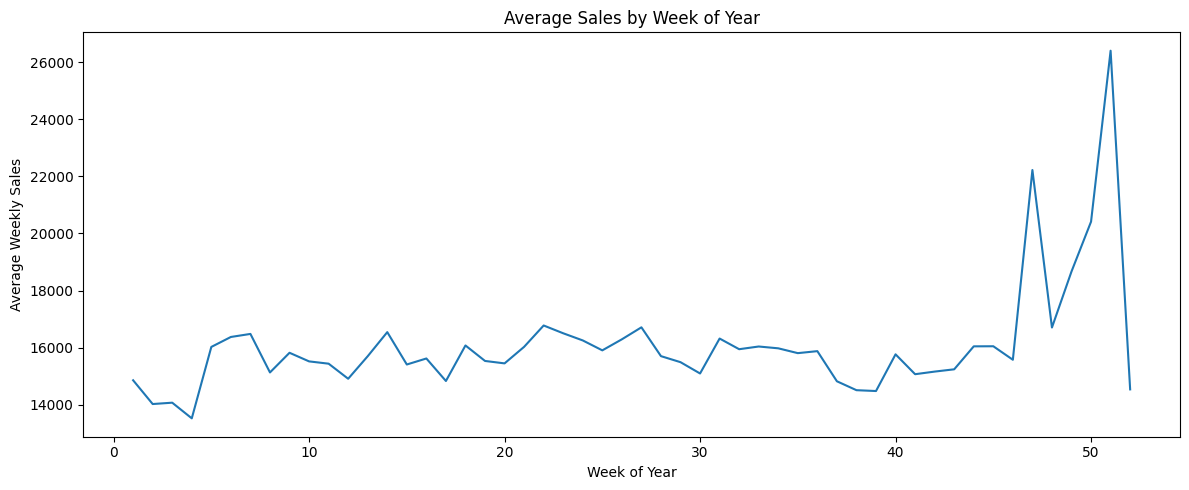

In [50]:
week_of_year_sales = (
    train_merged.groupby("WeekOfYear", as_index=False)["Weekly_Sales"]
    .mean()
)

plt.figure(figsize=(12, 5))
plt.plot(
    week_of_year_sales["WeekOfYear"],
    week_of_year_sales["Weekly_Sales"],
)
plt.title("Average Sales by Week of Year")
plt.xlabel("Week of Year")
plt.ylabel("Average Weekly Sales")
plt.tight_layout()
plt.show()

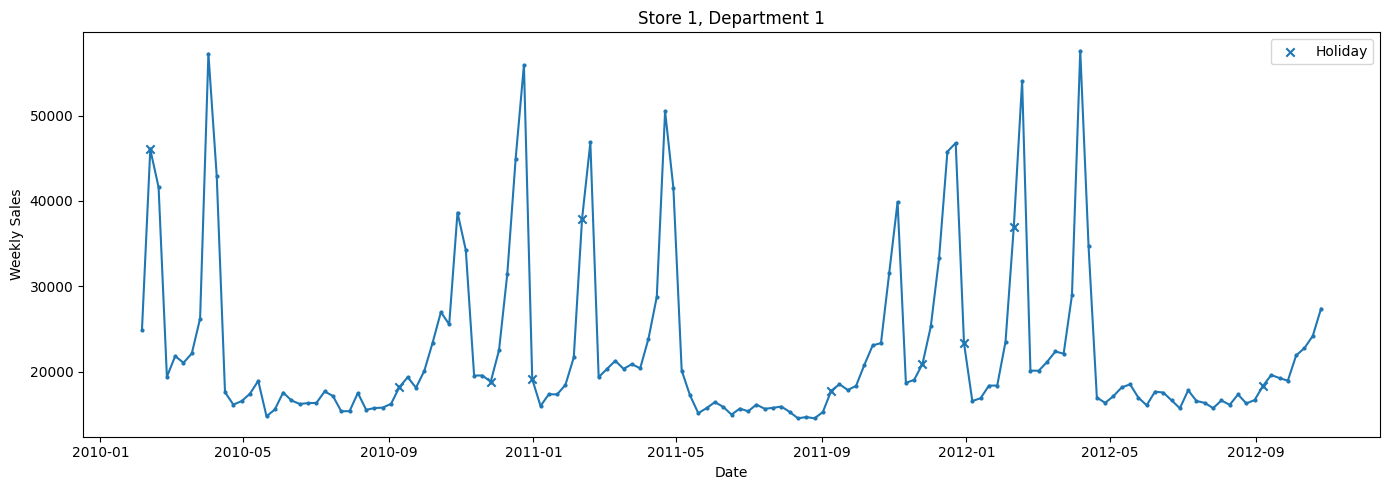

In [51]:
def plot_store_department(
    df: pd.DataFrame,
    store: int,
    department: int,
) -> None:
    selected = df[
        (df["Store"] == store)
        & (df["Dept"] == department)
    ].sort_values("Date")

    if selected.empty:
        print(
            f"No data found for Store {store}, "
            f"Department {department}."
        )
        return

    plt.figure(figsize=(14, 5))
    plt.plot(
        selected["Date"],
        selected["Weekly_Sales"],
        marker="o",
        markersize=2,
    )

    holiday_rows = selected[selected["IsHoliday"]]

    plt.scatter(
        holiday_rows["Date"],
        holiday_rows["Weekly_Sales"],
        marker="x",
        label="Holiday",
    )

    plt.title(
        f"Store {store}, Department {department}"
    )
    plt.xlabel("Date")
    plt.ylabel("Weekly Sales")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_store_department(
    train_merged,
    store=1,
    department=1,
)

In [52]:
top_pairs = (
    train.groupby(["Store", "Dept"])["Weekly_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

display(top_pairs)

Store  Dept
14     92     26,101,497.71
2      92     23,572,153.03
20     92     23,542,625.04
13     92     23,170,876.20
4      92     22,789,210.43
20     95     21,537,795.62
4      95     21,054,815.74
27     92     20,952,094.22
14     95     20,655,911.35
2      95     20,533,191.52
Name: Weekly_Sales, dtype: float64

In [53]:
def check_weekly_continuity(
    group: pd.DataFrame,
) -> pd.Series:
    dates = group["Date"].drop_duplicates().sort_values()
    differences = dates.diff().dropna()

    return pd.Series({
        "observations": len(dates),
        "first_date": dates.min(),
        "last_date": dates.max(),
        "non_weekly_gaps": (differences != pd.Timedelta(days=7)).sum(),
        "largest_gap_days": (
            differences.dt.days.max()
            if not differences.empty
            else 0
        ),
    })


continuity_report = (
    train.groupby(["Store", "Dept"])
    .apply(check_weekly_continuity, include_groups=False)
    .reset_index()
)

display(
    continuity_report.sort_values(
        "non_weekly_gaps",
        ascending=False,
    ).head(20)
)

,Store,Dept,observations,first_date,last_date,non_weekly_gaps,largest_gap_days
1184,16,45,66,2010-02-05,2012-10-26,36,56
3221,44,31,81,2010-02-12,2012-10-26,35,49
2404,32,45,79,2010-02-05,2012-10-19,35,42
1802,24,45,54,2010-02-12,2012-06-22,34,56
2111,28,45,64,2010-02-05,2012-07-13,33,63
3036,41,45,85,2010-02-05,2012-10-26,32,56
494,7,45,85,2010-02-05,2012-10-19,32,42
874,12,45,82,2010-02-05,2012-08-17,31,49
1494,20,45,41,2010-02-05,2012-07-27,31,77
951,13,45,91,2010-02-05,2012-10-19,30,56


In [54]:
comparison_columns = [
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5",
    "Size",
]

comparison_rows = []

for column in comparison_columns:
    if (
        column not in train_merged.columns
        or column not in test_merged.columns
    ):
        continue

    comparison_rows.append({
        "feature": column,
        "train_mean": train_merged[column].mean(),
        "test_mean": test_merged[column].mean(),
        "train_median": train_merged[column].median(),
        "test_median": test_merged[column].median(),
        "train_missing_pct": (
            train_merged[column].isna().mean() * 100
        ),
        "test_missing_pct": (
            test_merged[column].isna().mean() * 100
        ),
    })

distribution_comparison = pd.DataFrame(comparison_rows)

display(distribution_comparison)

,feature,train_mean,test_mean,train_median,test_median,train_missing_pct,test_missing_pct
0,Temperature,60.09,53.94,62.09,54.47,0.00,0.00
1,Fuel_Price,3.36,3.58,3.45,3.61,0.00,0.00
2,CPI,171.20,176.96,182.32,192.30,0.00,33.17
3,Unemployment,7.96,6.87,7.87,6.81,0.00,33.17
4,MarkDown1,"7,246.42","7,689.22","5,347.45","4,842.29",64.26,0.13
5,MarkDown2,"3,334.63","3,734.05",192.00,742.59,73.61,24.88
6,MarkDown3,"1,439.42","2,403.09",24.60,78.26,67.48,8.54
7,MarkDown4,"3,383.17","3,356.22","1,481.31",840.94,67.98,11.20
8,MarkDown5,"4,628.98","3,922.68","3,359.45","2,390.43",64.08,0.00
9,Size,"136,727.92","136,497.69","140,167.00","140,167.00",0.00,0.00


In [55]:
future_feature_availability = (
    test_merged
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

display(
    future_feature_availability[
        future_feature_availability > 0
    ].to_frame("missing_pct")
)

,missing_pct
Unemployment,33.17
CPI,33.17
MarkDown2,24.88
MarkDown4,11.20
MarkDown3,8.54
MarkDown1,0.13


In [58]:
def weighted_mean_absolute_error(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    is_holiday: np.ndarray,
) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    is_holiday = np.asarray(is_holiday, dtype=bool)

    if not (
        len(y_true)
        == len(y_pred)
        == len(is_holiday)
    ):
        raise ValueError(
            "y_true, y_pred, and is_holiday must have "
            "the same length."
        )

    weights = np.where(is_holiday, 5.0, 1.0)

    return np.sum(
        weights * np.abs(y_true - y_pred)
    ) / np.sum(weights)

In [59]:
example_true = np.array([100, 200, 300])
example_pred = np.array([90, 250, 280])
example_holiday = np.array([False, True, False])

score = weighted_mean_absolute_error(
    example_true,
    example_pred,
    example_holiday,
)

print("Example WMAE:", score)

Example WMAE: 40.0


In [60]:
unique_dates = np.sort(
    train_merged["Date"].dropna().unique()
)

validation_weeks = 12
validation_start = unique_dates[-validation_weeks]

train_split = train_merged[
    train_merged["Date"] < validation_start
].copy()

validation_split = train_merged[
    train_merged["Date"] >= validation_start
].copy()

print("Training period:")
print(
    train_split["Date"].min(),
    "to",
    train_split["Date"].max(),
)

print("\nValidation period:")
print(
    validation_split["Date"].min(),
    "to",
    validation_split["Date"].max(),
)

print("\nTraining rows:", len(train_split))
print("Validation rows:", len(validation_split))

Training period:
2010-02-05 00:00:00 to 2012-08-03 00:00:00

Validation period:
2012-08-10 00:00:00 to 2012-10-26 00:00:00

Training rows: 386007
Validation rows: 35563


In [61]:
last_known_sales = (
    train_split.sort_values("Date")
    .groupby(["Store", "Dept"])["Weekly_Sales"]
    .last()
    .rename("Prediction")
    .reset_index()
)

validation_baseline = validation_split.merge(
    last_known_sales,
    on=["Store", "Dept"],
    how="left",
)

global_median = train_split["Weekly_Sales"].median()

validation_baseline["Prediction"] = (
    validation_baseline["Prediction"]
    .fillna(global_median)
)

baseline_wmae = weighted_mean_absolute_error(
    validation_baseline["Weekly_Sales"],
    validation_baseline["Prediction"],
    validation_baseline["IsHoliday"],
)

print("Last-value baseline WMAE:", baseline_wmae)

Last-value baseline WMAE: 2237.003428215995


In [62]:
historical_lookup = train_split[
    ["Store", "Dept", "Date", "Weekly_Sales"]
].copy()

historical_lookup["Date"] = (
    historical_lookup["Date"]
    + pd.Timedelta(weeks=52)
)

historical_lookup = historical_lookup.rename(
    columns={"Weekly_Sales": "Seasonal_Prediction"}
)

seasonal_validation = validation_split.merge(
    historical_lookup,
    on=["Store", "Dept", "Date"],
    how="left",
)

fallback_values = (
    train_split.groupby(["Store", "Dept"])["Weekly_Sales"]
    .median()
    .rename("Series_Median")
    .reset_index()
)

seasonal_validation = seasonal_validation.merge(
    fallback_values,
    on=["Store", "Dept"],
    how="left",
)

seasonal_validation["Seasonal_Prediction"] = (
    seasonal_validation["Seasonal_Prediction"]
    .fillna(seasonal_validation["Series_Median"])
    .fillna(global_median)
)

seasonal_wmae = weighted_mean_absolute_error(
    seasonal_validation["Weekly_Sales"],
    seasonal_validation["Seasonal_Prediction"],
    seasonal_validation["IsHoliday"],
)

print("52-week seasonal baseline WMAE:", seasonal_wmae)

52-week seasonal baseline WMAE: 1713.3471030214857


In [63]:
def print_eda_report(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
) -> None:
    print("=" * 70)
    print("WALMART DATASET REPORT")
    print("=" * 70)

    print("\nTRAIN")
    print(f"Rows: {len(train_df):,}")
    print(f"Columns: {train_df.shape[1]}")
    print(
        f"Date range: {train_df['Date'].min()} "
        f"to {train_df['Date'].max()}"
    )
    print(f"Stores: {train_df['Store'].nunique()}")
    print(f"Departments: {train_df['Dept'].nunique()}")
    print(
        "Store-department pairs:",
        train_df[["Store", "Dept"]]
        .drop_duplicates()
        .shape[0],
    )

    print("\nTARGET")
    print(train_df["Weekly_Sales"].describe())
    print(
        "Negative sales:",
        (train_df["Weekly_Sales"] < 0).sum(),
    )
    print(
        "Holiday rows:",
        train_df["IsHoliday"].sum(),
    )

    print("\nTEST")
    print(f"Rows: {len(test_df):,}")
    print(f"Columns: {test_df.shape[1]}")
    print(
        f"Date range: {test_df['Date'].min()} "
        f"to {test_df['Date'].max()}"
    )

    print("\nDUPLICATES")
    print(
        "Train duplicate keys:",
        train_df.duplicated(
            ["Store", "Dept", "Date"]
        ).sum(),
    )
    print(
        "Test duplicate keys:",
        test_df.duplicated(
            ["Store", "Dept", "Date"]
        ).sum(),
    )

    print("\nMISSING VALUES IN TRAIN")
    missing = (
        train_df.isna()
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )
    print(missing[missing > 0])


print_eda_report(train_merged, test_merged)

WALMART DATASET REPORT

TRAIN
Rows: 421,570
Columns: 21
Date range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00
Stores: 45
Departments: 81
Store-department pairs: 3331

TARGET
count   421,570.00
mean     15,981.26
std      22,711.18
min      -4,988.94
25%       2,079.65
50%       7,612.03
75%      20,205.85
max     693,099.36
Name: Weekly_Sales, dtype: float64
Negative sales: 1285
Holiday rows: 29661

TEST
Rows: 115,064
Columns: 20
Date range: 2012-11-02 00:00:00 to 2013-07-26 00:00:00

DUPLICATES
Train duplicate keys: 0
Test duplicate keys: 0

MISSING VALUES IN TRAIN
MarkDown2   73.61
MarkDown4   67.98
MarkDown3   67.48
MarkDown1   64.26
MarkDown5   64.08
dtype: float64
